In [13]:
import os
from dotenv import load_dotenv
from fredapi import Fred
import pandas as pd

load_dotenv()
fred_api_key = os.getenv("FRED_API_KEY")

fred = Fred(api_key=fred_api_key)

series = {
    "yield curve spread": "T10Y2Y",
    "unemployment rate": "UNRATE",
    "CPI inflation": "CPIAUCSL",
    "GDP growth": "A191RL1Q225SBEA",
    "consumer confidence": "UMCSENT",
    "fed funds rate": "FEDFUNDS",
    "recession indicator": "USREC",
}

data_list = []
for name, code in series.items():
    data = fred.get_series(code, observation_start="1980-01-01")
    data.name = name
    data_list.append(data)

df = pd.concat(data_list, axis=1, sort=False)

df.to_csv("data/raw/macro_data.csv")

In [14]:
print(df.head())

print(df.shape)

print(df.info(verbose=True, show_counts=True))

print(df.describe())

            yield curve spread  unemployment rate  CPI inflation  GDP growth  \
1980-01-01                 NaN                6.3           78.0         1.3   
1980-01-02               -0.89                NaN            NaN         NaN   
1980-01-03               -0.85                NaN            NaN         NaN   
1980-01-04               -0.81                NaN            NaN         NaN   
1980-01-07               -0.72                NaN            NaN         NaN   

            consumer confidence  fed funds rate  recession indicator  
1980-01-01                 67.0           13.82                  0.0  
1980-01-02                  NaN             NaN                  NaN  
1980-01-03                  NaN             NaN                  NaN  
1980-01-04                  NaN             NaN                  NaN  
1980-01-07                  NaN             NaN                  NaN  
(12231, 7)
<class 'pandas.DataFrame'>
DatetimeIndex: 12231 entries, 1980-01-01 to 2026-03-01


In [15]:
df_monthly = df.resample("ME").mean()

# print(df_monthly.info(verbose=True, show_counts=True))

df_monthly = df_monthly.ffill()

print(df_monthly.info(verbose=True, show_counts=True))
# print(df_monthly.isnull().sum())

df_monthly.shape

<class 'pandas.DataFrame'>
DatetimeIndex: 556 entries, 1980-01-31 to 2026-04-30
Freq: ME
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   yield curve spread   556 non-null    float64
 1   unemployment rate    556 non-null    float64
 2   CPI inflation        556 non-null    float64
 3   GDP growth           556 non-null    float64
 4   consumer confidence  556 non-null    float64
 5   fed funds rate       556 non-null    float64
 6   recession indicator  556 non-null    float64
dtypes: float64(7)
memory usage: 34.8 KB
None


(556, 7)

In [16]:
print(df_monthly.head())
print(df_monthly.tail())

            yield curve spread  unemployment rate  CPI inflation  GDP growth  \
1980-01-31           -0.695909                6.3           78.0         1.3   
1980-02-29           -1.003684                6.3           79.0         1.3   
1980-03-31           -2.135714                6.3           80.1         1.3   
1980-04-30           -1.028571                6.9           80.9        -8.0   
1980-05-31            0.731429                7.5           81.7        -8.0   

            consumer confidence  fed funds rate  recession indicator  
1980-01-31                 67.0           13.82                  0.0  
1980-02-29                 66.9           14.13                  1.0  
1980-03-31                 56.5           17.19                  1.0  
1980-04-30                 52.7           17.61                  1.0  
1980-05-31                 51.7           10.98                  1.0  
            yield curve spread  unemployment rate  CPI inflation  GDP growth  \
2025-12-31   

In [17]:
df_monthly.to_csv("data/macro_data_clean.csv")

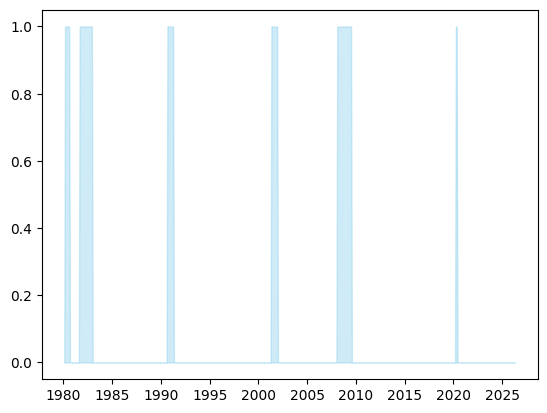

In [18]:
import matplotlib.pyplot as plt

plt.fill_between(df_monthly.index, df_monthly["recession indicator"], color="skyblue", alpha=0.4)
